# $\varepsilon$-Pseudospectra of Magnetic Advection–Diffusion Operators by Partial Schur Projection

**L-shaped domain $\Omega = [0,2]^2 \setminus [1,2]^2$, re-entrant corner at $(1,1)$.**

This notebook is entirely self-contained: every mesh constructor, finite element space,
bilinear form and solver routine used below is defined *in this notebook*, so it does not
import anything from `functions.py` or `pseudospectra.py`.

---

## 1. What is being computed

For a matrix pencil $(A, M)$ coming from a mixed finite element discretisation, the
$\varepsilon$-pseudospectrum is taken in the sense of van Dorsselaer / Frayssé for
*generalised* eigenvalue problems,

$$
\sigma_\varepsilon(A, M)
  \;=\; \bigl\{\, z \in \mathbb{C} \;:\; \|(zM - A)^{-1}\|_2 \ \ge\ \varepsilon^{-1} \,\bigr\}
  \;=\; \bigl\{\, z \in \mathbb{C} \;:\; \sigma_{\min}(zM - A) \ \le\ \varepsilon \,\bigr\},
$$

with $\sigma_{\min}$ the smallest singular value and $\sigma_{\min}(zM-A) := 0$ whenever
$zM - A$ is singular (i.e. at an eigenvalue).  Plotting the level sets of
$z \mapsto \sigma_{\min}(zM - A)$ therefore draws every $\varepsilon$-pseudospectrum at once.

For a **normal** operator the level sets are exact discs of radius $\varepsilon$ about the
eigenvalues; the amount by which they bulge beyond those discs is a direct, quantitative
measure of **non-normality**, which for magnetic advection–diffusion is driven by the wind
$\mathbf{u}$ and grows with the magnetic Reynolds number $R_m$.

## 2. The algorithm: partial Schur projection

Evaluating $\sigma_{\min}(zM - A)$ directly is a dense SVD of an $N \times N$ matrix at every
point $z$, which is hopeless for $N \sim 10^4$.  The six steps below reduce it to an SVD of an
$m \times m$ triangular pencil with $m \sim 10^2$.

| Step | Object | Tool |
|---|---|---|
| 1 | Saddle-point pencil $(A, M)$, $M$ has a **zero block** | Firedrake |
| 2 | Reciprocal shift-and-invert about a target $\tau$ | SLEPc `EPS` + `ST` |
| 3 | Orthonormal partial Schur basis $Q \in \mathbb{C}^{N \times m}$, and the projection $A_m = Q^{*} A Q$, $M_m = Q^{*} M Q$ | PETSc + NumPy |
| 4 | Generalised Schur (QZ): $A_m = W^{*} S V$, $M_m = W^{*} T V$, with $S, T$ upper triangular | `scipy.linalg.qz` |
| 5 | $\mathcal{R}(z) = \sigma_{\min}(S - zT)$ at $2000$ **random** points $z$ in a bounding box | `scipy.linalg.svdvals` |
| 6 | Scattered $\to$ regular grid, contour at $\varepsilon = 10^{-1}, 10^{-2}, \dots$ | `scipy.interpolate.griddata` |

**Why the QZ step is legitimate.**  $W$ and $V$ are unitary, so for every $z$

$$
S - zT \;=\; W \bigl(A_m - z M_m\bigr) V^{*}
\qquad\Longrightarrow\qquad
\sigma_{\min}(S - zT) \;=\; \sigma_{\min}(A_m - z M_m),
$$

because singular values are invariant under unitary transformations.  The QZ factorisation is
computed **once**; each of the $2000$ evaluations is then an SVD of a triangular matrix.

**Why the answer is an inner approximation.**  $Q$ is a *one-sided* (Galerkin) basis for the
right invariant subspace, not a deflating pair, so
$\sigma_{\min}(S - zT) \ge \sigma_{\min}(zM - A)$: the plotted $\varepsilon$-contour is contained
in the true one, and it converges from above as $m$ grows.  Section 10 checks this by
re-running with larger $m$ — the contours must have stopped moving before any of this is
quoted.

---
## 3. Imports and plotting style

In [1]:
import numpy as np
import scipy.linalg as sla
from scipy.interpolate import griddata

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from firedrake import *
from firedrake.cython import dmcommon
from firedrake.mesh import plex_from_cell_list
from firedrake.pyplot import triplot

from petsc4py import PETSc
from slepc4py import SLEPc

# Imported AFTER the star-import, and under another name: firedrake exports a
# `logging` of its own which would otherwise shadow the standard library module.
# triplot re-queries the DMPlex face labels and reports every one of them empty
# even when they are marked correctly, so quieten it.
import logging as pylogging
pylogging.getLogger("firedrake").setLevel(pylogging.ERROR)
pylogging.getLogger("fontTools").setLevel(pylogging.ERROR)

# PETSc here is built with REAL scalars: SLEPc returns a complex eigenvector as a
# pair (real part, imaginary part) of separate real vectors.  Every routine below
# is written for that case and also works unchanged in a complex build.
COMPLEX_PETSC = np.issubdtype(PETSc.ScalarType, np.complexfloating)
print(f"PETSc scalar type : {PETSc.ScalarType.__name__} "
      f"({'complex' if COMPLEX_PETSC else 'real'} build)")

# Publication style, identical to the one used for the other pseudospectrum
# figures in this study (serif text, Computer Modern maths, hairline axes).
PS_RC = {
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02, "ps.fonttype": 42,
}

PETSc scalar type : float64 (real build)


---
## 4. The L-shaped mesh

$$\Omega \;=\; [0,2]^2 \setminus [1,2]^2,$$

a uniform $2n \times 2n$ grid on $[0,2]^2$ with the top-right quadrant removed and each
remaining square split into four triangles about its centre (`crossed`).

The **re-entrant corner sits at $(1,1)$**, with interior angle $3\pi/2$.  That corner is the
whole point of the geometry: it limits the elliptic regularity of the eigenfunctions to
$H^{1+2/3-\delta}$, and it is where the discontinuity of the shear wind
$\mathbf{u} = (\operatorname{sign}(y-1), 0)$ crosses the domain — the line $y = 1$ runs from the
outer boundary $x=0$ straight into the corner.

Boundary markers: `1`: $x=0$, `2`: $x=2$, `3`: $y=0$, `4`: $y=2$, `5`: $x=1$ (re-entrant),
`6`: $y=1$ (re-entrant).

In [2]:
def make_Lshape_mesh(n=16, diagonal="crossed", comm=COMM_WORLD, name="L_shape_02"):
    r"""Structured mesh of the L-shaped domain [0, 2]^2 \ [1, 2]^2.

    The re-entrant corner is at (1, 1), with interior angle 3*pi/2.

    Parameters
    ----------
    n : int
        Cells per unit length, so the enclosing square carries 2n per side.
    diagonal : {"crossed", "left", "right"}
        How each grid square is split into triangles, as in RectangleMesh.

    Returns
    -------
    Mesh
        with boundary markers

            1 : x = 0                      4 : y = 2  (0 <= x <= 1)
            2 : x = 2  (0 <= y <= 1)       5 : x = 1  (1 <= y <= 2)  re-entrant
            3 : y = 0                      6 : y = 1  (1 <= x <= 2)  re-entrant
    """
    if n < 1:
        raise ValueError("n must be a positive integer")
    if diagonal not in ("crossed", "left", "right"):
        raise ValueError(f"Unknown diagonal '{diagonal}'")

    h = 1.0 / n
    N = 2 * n

    # Vertex (i, j) sits at (i*h, j*h) and has index i*(N+1) + j.
    grid = np.arange(N + 1) * h
    gx, gy = np.meshgrid(grid, grid, indexing="ij")
    coords = np.column_stack([gx.ravel(), gy.ravel()])

    # Drop the top-right quadrant: x >= 1 <=> i >= n, and y >= 1 <=> j >= n.
    i, j = np.meshgrid(np.arange(N), np.arange(N), indexing="ij")
    keep = ~((i >= n) & (j >= n))
    i, j = i[keep], j[keep]

    # Corners of each retained square, counter-clockwise from bottom-left.
    v00 = i * (N + 1) + j
    v10 = v00 + (N + 1)
    v11 = v10 + 1
    v01 = v00 + 1

    if diagonal == "right":
        cells = np.vstack([np.column_stack([v00, v10, v11]),
                           np.column_stack([v00, v11, v01])])
    elif diagonal == "left":
        cells = np.vstack([np.column_stack([v00, v10, v01]),
                           np.column_stack([v10, v11, v01])])
    else:
        # "crossed": one extra vertex per square, four triangles per square.
        # Symmetric about both diagonals, so it does not bias the corner
        # singularity in either coordinate direction.
        centre = len(coords) + np.arange(len(i))
        coords = np.vstack([coords,
                            np.column_stack([(i + 0.5) * h, (j + 0.5) * h])])
        cells = np.vstack([np.column_stack([v00, v10, centre]),
                           np.column_stack([v10, v11, centre]),
                           np.column_stack([v11, v01, centre]),
                           np.column_stack([v01, v00, centre])])

    # Drop unreferenced vertices (those of the removed quadrant) and renumber.
    used, inverse = np.unique(cells, return_inverse=True)
    cells = inverse.reshape(-1, 3)
    coords = coords[used]

    plex = plex_from_cell_list(2, cells, coords, comm)
    _mark_lshape_boundaries(plex, tol=0.25 * h)
    return Mesh(plex, name=name, comm=comm)


def _mark_lshape_boundaries(plex, tol):
    """Tag the six boundary segments; see make_Lshape_mesh for the markers."""
    plex.createLabel(dmcommon.FACE_SETS_LABEL)
    plex.markBoundaryFaces("boundary_faces")

    if plex.getStratumSize("boundary_faces", 1) > 0:
        coords = plex.getCoordinates()
        coord_sec = plex.getCoordinateSection()

        for face in plex.getStratumIS("boundary_faces", 1).getIndices():
            # Classify each boundary edge by the midpoint of its two vertices.
            x, y = (plex.vecGetClosure(coord_sec, coords, face)
                    .reshape(-1, 2).mean(axis=0))

            if abs(x) < tol:
                marker = 1
            elif abs(x - 2.0) < tol:
                marker = 2
            elif abs(y) < tol:
                marker = 3
            elif abs(y - 2.0) < tol:
                marker = 4
            elif abs(x - 1.0) < tol:
                marker = 5
            elif abs(y - 1.0) < tol:
                marker = 6
            else:
                raise RuntimeError(
                    f"Could not classify boundary face with midpoint ({x}, {y})")

            plex.setLabelValue(dmcommon.FACE_SETS_LABEL, face, marker)

    plex.removeLabel("boundary_faces")

cells      : 3072
vertices   : 1601
h          : 0.0625
area       : 3.000000000000   (expected 3)
boundaries : [2.0, 1.0, 2.0, 1.0, 1.0, 1.0]


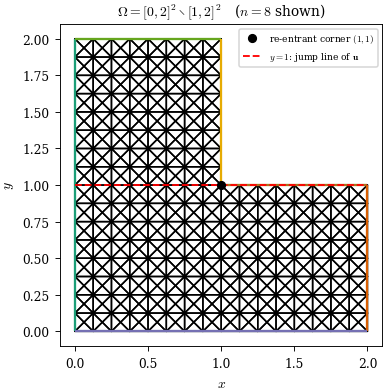

In [3]:
MESH_N = 16                      # cells per unit length -> h = 1/16
mesh = make_Lshape_mesh(n=MESH_N, diagonal="crossed")

# Geometry checks, so the mesh is verified rather than assumed:
#   |Omega| = 4 - 1 = 3, and the six boundary segments have lengths
#   2, 1, 2, 1, 1, 1  (total perimeter 8).
area = float(assemble(Constant(1.0) * dx(domain=mesh)))
lengths = [float(assemble(Constant(1.0) * ds(k, domain=mesh))) for k in range(1, 7)]
assert abs(area - 3.0) < 1e-12
assert np.allclose(lengths, [2.0, 1.0, 2.0, 1.0, 1.0, 1.0])
print(f"cells      : {mesh.num_cells()}")
print(f"vertices   : {mesh.num_vertices()}")
print(f"h          : {1.0 / MESH_N}")
print(f"area       : {area:.12f}   (expected 3)")
print(f"boundaries : {[round(v, 12) for v in lengths]}")

with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(3.8, 3.8))
    triplot(make_Lshape_mesh(n=8), axes=ax)      # coarse copy, to see the geometry
    jump, = ax.plot([0, 2], [1, 1], "r--", lw=1.2, zorder=5,
                    label=r"$y=1$: jump line of $\mathbf{u}$")
    corner, = ax.plot([1], [1], "ko", ms=5, zorder=6,
                      label="re-entrant corner $(1,1)$")
    ax.set_aspect("equal")
    ax.set_title(r"$\Omega=[0,2]^2\setminus[1,2]^2$   ($n=8$ shown)")
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    # Only these two handles: triplot also registers one entry per boundary marker.
    ax.legend(handles=[corner, jump], loc="upper right", fontsize=6)
    plt.show()

---
## 5. Velocity fields (winds)

Two wind conditions are run for every formulation.

| key | $\mathbf{u}$ | regularity | role |
|---|---|---|---|
| `W0` | $\mathbf{0}$ | — | **self-adjoint baseline.** With no advection the operator is symmetric, the spectrum is real, and the pseudospectra must be (near-)circular discs. Any bulging here is numerical, not physical. |
| `W3` | $(\operatorname{sign}(y-1),\, 0)$ | $L^\infty$ but **not** $W^{1,\infty}$ | **discontinuous shear.** Divergence free ($\partial_x u_1 = 0$, $u_2 \equiv 0$), so it does not perturb the constraint, but its jump line $y=1$ runs into the re-entrant corner. This is the case that breaks normality. |

Note that $\varepsilon_{\text{diff}} = 1/R_m$ multiplies **only** the diffusion term; the advective
term carries no $R_m$.  Raising $R_m$ therefore weakens diffusion relative to advection and is
what drives the operator away from normality.  With $\mathbf{u} = \mathbf{0}$ the operator stays
self-adjoint at every $R_m$, and $R_m$ merely rescales the spectrum by $1/R_m$.

In [4]:
def wind_W0(mesh):
    """u = 0.  Returned as None, which drops the advective term from the form
    entirely rather than assembling a zero matrix."""
    return None


def wind_W3(mesh, y0=1.0):
    """u = (sign(y - y0), 0): a Heaviside shear layer along y = y0.

    Divergence free (u_1 depends on y only, u_2 = 0) but discontinuous, so it is
    in L^inf and not in W^{1,inf}.  On this domain y0 = 1 puts the jump line
    directly through the re-entrant corner at (1, 1).
    """
    x, y = SpatialCoordinate(mesh)
    return as_vector([sign(y - Constant(y0)), Constant(0.0)])


WINDS = {
    "W0": (r"$\mathbf{u}=\mathbf{0}$", wind_W0),
    "W3": (r"$\mathbf{u}=(\mathrm{sign}(y-1),\,0)$", wind_W3),
}

---
## 6. The three formulations

### 6.1 $B$-formulation — continuous problem

The magnetic field $\mathbf{B}$ is a **1-form**.  In 2D the curl of a vector field is a scalar,
$\operatorname{curl}\mathbf{B} = \partial_x B_2 - \partial_y B_1$, and the cross product of two
planar vectors is the scalar $(\mathbf{a}\times\mathbf{b})_z = a_1 b_2 - a_2 b_1$.

Find $\lambda \in \mathbb{C}$ and $(\mathbf{B}, p) \in H_0(\operatorname{curl};\Omega) \times H_0^1(\Omega)$,
$\mathbf{B} \ne \mathbf{0}$, such that for all $(\mathbf{C}, q)$

$$
\begin{aligned}
\varepsilon\,\bigl(\operatorname{curl}\mathbf{B},\, \operatorname{curl}\mathbf{C}\bigr)
\;+\; \bigl(\mathbf{B}\times\mathbf{u},\, \operatorname{curl}\mathbf{C}\bigr)
\;-\; \bigl(\nabla p,\, \mathbf{C}\bigr) &= \lambda\,\bigl(\mathbf{B}, \mathbf{C}\bigr), \\[2pt]
\bigl(\mathbf{B},\, \nabla q\bigr) &= 0 ,
\end{aligned}
\qquad \varepsilon = 1/R_m .
$$

The strong form is $\varepsilon\operatorname{curl}\operatorname{curl}\mathbf{B} + \operatorname{curl}(\mathbf{B}\times\mathbf{u}) - \nabla p = \lambda\mathbf{B}$
together with $\operatorname{div}\mathbf{B} = 0$.  The Lagrange multiplier $p$ enforces the
solenoidal constraint weakly; the boundary condition is the perfectly-conducting one,
$\mathbf{B}\times\mathbf{n} = 0$ (zero tangential trace), together with $p = 0$.

### 6.2 $B$-formulation — discrete spaces

Two members of the discrete de Rham complex $\mathrm{CG} \xrightarrow{\ \nabla\ } H(\operatorname{curl})$
are used, and this is the *only* difference between `B(N1)` and `B(N2)`:

$$
\textbf{B(N1)}: \quad W_h = \mathrm{N1curl}_r \times \mathrm{CG}_r
\qquad\qquad
\textbf{B(N2)}: \quad W_h = \mathrm{N2curl}_r \times \mathrm{CG}_{r+1}
$$

`N1curl` is the *trimmed* (Nédélec first kind) space, `N2curl` the *full* (second kind) space.
Both pairs make $\nabla(\mathrm{CG}) \subseteq H(\operatorname{curl})_h$ exactly, which is what makes
the discrete constraint compatible; `N2curl` has the larger polynomial space at equal $r$ and
therefore many more degrees of freedom.

### 6.3 $A$-formulation — continuous problem

In 2D the magnetic field derives from a **scalar** potential (a 0-form),
$\mathbf{B} = \operatorname{curl} A = (\partial_y A,\, -\partial_x A)$, which satisfies
$\operatorname{div}\mathbf{B} = 0$ identically — the constraint is built in, so there is no
saddle point coming from it.  What is left undetermined is the additive constant in $A$, and
that gauge freedom is fixed by a single real multiplier $t \in \mathbb{R}$:

$$
\begin{aligned}
\varepsilon\,(\nabla A, \nabla z) \;+\; (\mathbf{u}\cdot\nabla A,\, z) \;-\; (t,\, z) &= \lambda\,(A, z)
&& \forall z \in H^1(\Omega), \\[2pt]
(A,\, s) &= 0 && \forall s \in \mathbb{R}.
\end{aligned}
$$

No Dirichlet condition is imposed: the natural condition $\partial A/\partial n = 0$ is exactly
equivalent to $\mathbf{B}\times\mathbf{n} = 0$ in the $B$-formulation, which is why the two give the
same spectrum (checked numerically in section 9).  Without the multiplier the pencil would
carry a genuine eigenvalue at $\lambda = 0$ from the constant mode; the constraint removes it
structurally so nothing has to be filtered by hand.

### 6.4 $A$-formulation — discrete space and why it is assembled by hand

$V_h = \mathrm{CG}_r$.  Firedrake refuses monolithic assembly of a mixed space containing an
`"R"` block, and the `MATNEST` it does produce can neither be converted to AIJ nor factorised
by MUMPS — which the shift-and-invert transformation requires.  Since the constraint is only a
**rank-one border**, it is applied directly to the assembled $\mathrm{CG}$ blocks:

$$
A \;=\; \begin{bmatrix} K & -g \\ -g^{\mathsf T} & 0\end{bmatrix},
\qquad
M \;=\; \begin{bmatrix} M_{\mathrm{CG}} & 0 \\ 0 & 0 \end{bmatrix},
\qquad
g_i = \int_\Omega \phi_i \,\mathrm{d}x .
$$

The sign is negative on both off-diagonal blocks so that $A$ stays symmetric when
$\mathbf{u} = \mathbf{0}$.

In [5]:
# ---------------------------------------------------------------------------
# Function spaces
# ---------------------------------------------------------------------------

def FEEC_B_N1_2d1k(mesh, degree):
    """Trimmed FEEC mixed space for the B-formulation, 2D, k = 1.

    Discrete de Rham sequence:   CG_r --grad--> N1curl_r
    (N1curl = Nedelec FIRST kind / trimmed H(curl)-conforming space.)

    Returns W_h = N1curl_r x CG_r, carrying (v, p) = (magnetic field, multiplier).
    """
    return (FunctionSpace(mesh, "N1curl", degree)
            * FunctionSpace(mesh, "CG", degree))


def FEEC_B_N2_2d1k(mesh, degree):
    """Full FEEC mixed space for the B-formulation, 2D, k = 1.

    Discrete de Rham sequence:   CG_{r+1} --grad--> N2curl_r
    (N2curl = Nedelec SECOND kind / full H(curl)-conforming space.)

    Returns W_h = N2curl_r x CG_{r+1}.  The scalar space must be one degree
    higher than for N1curl so that grad(CG_{r+1}) still lands inside N2curl_r.
    """
    return (FunctionSpace(mesh, "N2curl", degree)
            * FunctionSpace(mesh, "CG", degree + 1))


def FEEC_A_2d1k(mesh, degree):
    """FEEC space for the A-formulation: A is a discrete 0-form, so CG_r.

    NOT a mixed space -- the real-valued gauge multiplier is added afterwards as
    a rank-one border on the assembled matrices (see A_formulation_2d1k).
    """
    return FunctionSpace(mesh, "CG", degree)


# ---------------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------------

def cross2d(a, b):
    """Scalar 2D cross product: the z-component of the 3D cross product,

        (a x b)_z = a_1 b_2 - a_2 b_1.

    Antisymmetric, so the ordering matters: the B-formulation needs
    cross2d(v, u), i.e. v x u, not u x v.
    """
    return a[0] * b[1] - a[1] * b[0]

In [6]:
# ---------------------------------------------------------------------------
# B-formulation
# ---------------------------------------------------------------------------

def B_formulation_2d1k(W, u=None, eps=Constant(1.0)):
    """Mixed 2D B-formulation of the generalised eigenvalue problem a(.,.) = lam m(.,.).

    Parameters
    ----------
    W   : mixed FunctionSpace  H(curl)_h x CG_h
    u   : background velocity field (UFL expression) or None for zero wind
    eps : diffusion coefficient, eps = 1/Rm

    Returns
    -------
    (a, m) : the two bilinear forms.  Note that `m` involves ONLY the vector
             component, so the assembled mass matrix has a ZERO BLOCK on the
             multiplier diagonal -- this is exactly the singularity that the
             shift-and-invert transformation in section 7.2 has to bypass.
    """
    (v, p) = TrialFunctions(W)     # v: magnetic field, p: Lagrange multiplier
    (w, q) = TestFunctions(W)

    # Curl-curl (diffusion) term:  eps (curl v, curl w).
    a = eps * inner(curl(v), curl(w)) * dx

    # Advection term:  (v x u, curl w).  Dropped entirely when u is None, so the
    # zero-wind pencil is exactly symmetric rather than symmetric-up-to-roundoff.
    if u is not None:
        a += inner(cross2d(v, u), curl(w)) * dx

    # Saddle-point coupling: -(grad p, w) + (v, grad q).  The second row is the
    # weak solenoidal constraint; the antisymmetric sign pattern keeps the whole
    # block matrix symmetric when u is None.
    a += (-inner(grad(p), w) + inner(v, grad(q))) * dx

    # L2 mass form for the vector field only.
    m = inner(v, w) * dx

    return a, m


def bcs_B_2d1k(W):
    """Homogeneous Dirichlet data for the B-formulation.

    On an H(curl) space Firedrake constrains the TANGENTIAL trace, so this is
    the perfectly conducting condition v x n = 0, plus p = 0 for the multiplier.
    """
    bc_v = DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary")
    bc_p = DirichletBC(W.sub(1), Constant(0.0), "on_boundary")
    return [bc_v, bc_p]

In [7]:
# ---------------------------------------------------------------------------
# A-formulation, with the real-number gauge multiplier applied as a rank-one border
# ---------------------------------------------------------------------------

def _border_rank_one(K, g):
    """Return [[K, -g], [-g^T, 0]] as a monolithic AIJ matrix.

    Done at the CSR level rather than with PETSc's nest/submatrix machinery so
    that the result is a plain AIJ matrix MUMPS can factorise.
    """
    n = K.getSize()[0]
    ai, aj, av = K.getValuesCSR()
    ai = ai.astype(np.int32)
    aj = aj.astype(np.int32)

    counts = np.diff(ai) + 1                       # every row gains the border column
    new_ai = np.zeros(n + 2, dtype=np.int32)
    new_ai[1:n + 1] = np.cumsum(counts)
    new_ai[n + 1] = new_ai[n] + n                  # the multiplier row is dense
    new_aj = np.empty(new_ai[-1], dtype=np.int32)
    new_av = np.empty(new_ai[-1], dtype=PETSc.ScalarType)

    # An existing entry in row i shifts right by i, because each earlier row
    # gained exactly one entry.
    row_of = np.repeat(np.arange(n, dtype=np.int32), np.diff(ai))
    pos = np.arange(aj.size, dtype=np.int32) + row_of
    new_aj[pos] = aj
    new_av[pos] = av

    extra = ai[1:] + np.arange(n, dtype=np.int32)  # the -g column
    new_aj[extra] = n
    new_av[extra] = -g

    new_aj[new_ai[n]:] = np.arange(n, dtype=np.int32)   # the -g^T row
    new_av[new_ai[n]:] = -g
    return PETSc.Mat().createAIJWithArrays((n + 1, n + 1), (new_ai, new_aj, new_av))


def _pad_zero_row(M):
    """Return M with one extra EMPTY row and column.

    This is what puts the zero block into the mass matrix of the A-formulation:
    the gauge multiplier carries no mass, so the pencil has an eigenvalue at
    infinity there, exactly as the pressure block does in the B-formulation.
    """
    n = M.getSize()[0]
    ai, aj, av = M.getValuesCSR()
    new_ai = np.empty(n + 2, dtype=np.int32)
    new_ai[:n + 1] = ai.astype(np.int32)
    new_ai[n + 1] = ai[n]
    return PETSc.Mat().createAIJWithArrays(
        (n + 1, n + 1), (new_ai, aj.astype(np.int32), av))


def A_formulation_2d1k(W, u=None, eps=Constant(1.0)):
    r"""A-formulation eigenproblem WITH the real-number gauge multiplier:

        eps (grad w, grad z) + (u . grad w, z) - (t, z) = lambda (w, z)   for all z in H^1
                                                (w, s) = 0               for all s in R

    Parameters
    ----------
    W   : the scalar CG space -- NOT a mixed space; the multiplier is the extra
          row and column added here.
    u   : background velocity field or None.
    eps : diffusion coefficient, 1/Rm.

    Returns
    -------
    (A_mat, M_mat) : PETSc.Mat, both of size W.dim() + 1.  The last entry of an
        eigenvector is the multiplier t; the leading W.dim() entries are the CG
        coefficients.  No boundary conditions: the natural condition dA/dn = 0
        is the counterpart of B x n = 0 in the B-formulation.
    """
    v = TrialFunction(W)
    w = TestFunction(W)

    a = eps * inner(grad(v), grad(w)) * dx
    if u is not None:
        a += inner(dot(u, grad(v)), w) * dx
    m = inner(v, w) * dx

    K = assemble(a).petscmat
    M = assemble(m).petscmat
    # g_i = integral of the i-th basis function: the discrete "mean value" functional.
    g = np.asarray(assemble(w * dx).dat.data_ro, dtype=PETSc.ScalarType).copy()
    return _border_rank_one(K, g), _pad_zero_row(M)

---
## 7. Step 1 & 2 — the saddle-point pencil and the shift-and-invert solve

### 7.1 Assembling $(A, M)$

Both discretisations produce a generalised pencil in which

$$
M \;=\; \begin{bmatrix} M_{\text{field}} & 0 \\ 0 & \boxed{0} \end{bmatrix}
$$

is **singular**: the multiplier block (the pressure $p$ for $B$, the gauge scalar $t$ for $A$)
carries no mass.  The pencil therefore has eigenvalues at $\infty$ with multiplicity equal to
the size of that block.  Any solver that works with $M^{-1}A$ is dead on arrival.

For the $B$-formulation the boundary conditions are applied through Firedrake's
`LinearEigenproblem` with `restrict=True`, which builds a `RestrictedFunctionSpace` that
*removes* the constrained degrees of freedom rather than pinning them with a large diagonal
entry — so no spurious eigenvalues are introduced at the boundary at all.

In [8]:
def build_pencil(form_name, mesh, wind, Rm, degree=1):
    """Assemble the (A, M) pencil for one formulation as raw PETSc matrices.

    Parameters
    ----------
    form_name : "B(N1)", "B(N2)" or "A"
    wind      : UFL velocity expression, or None for u = 0
    Rm        : magnetic Reynolds number; the diffusion coefficient is eps = 1/Rm

    Returns
    -------
    dict with keys A, M (PETSc.Mat), N (matrix size) and dof (space dimension).
    """
    eps = Constant(1.0 / Rm)

    if form_name == "A":
        # Already returns bordered PETSc matrices; no essential BCs.
        V = FEEC_A_2d1k(mesh, degree)
        A_mat, M_mat = A_formulation_2d1k(V, u=wind, eps=eps)
        return dict(A=A_mat, M=M_mat, N=A_mat.getSize()[0], dof=V.dim() + 1,
                    form=form_name)

    space = FEEC_B_N1_2d1k if form_name == "B(N1)" else FEEC_B_N2_2d1k
    W = space(mesh, degree)
    a, m = B_formulation_2d1k(W, u=wind, eps=eps)

    # restrict=True replaces W by a RestrictedFunctionSpace with the Dirichlet
    # degrees of freedom deleted, so the pencil contains no boundary rows at all.
    # weight=0.0 on the mass matrix reproduces exactly what Firedrake's
    # LinearEigensolver assembles, so the pencil here is bit-for-bit the one used
    # for the eigenvalue computations elsewhere in this study.
    prob = LinearEigenproblem(A=a, M=m, bcs=bcs_B_2d1k(W), restrict=True)
    A_mat = assemble(prob.A, bcs=prob.bcs).petscmat
    M_mat = assemble(prob.M, bcs=prob.bcs, weight=0.0).petscmat
    return dict(A=A_mat, M=M_mat, N=A_mat.getSize()[0], dof=W.dim(),
                form=form_name)

### 7.2 Reciprocal shift-and-invert

SLEPc's `ST` object is set to `SINVERT`, which replaces the pencil $(A, M)$ by the single
operator

$$
\mathcal{T}_\tau \;=\; (A - \tau M)^{-1} M ,
\qquad\text{whose eigenvalues are}\qquad
\theta \;=\; \frac{1}{\lambda - \tau}.
$$

This is the *reciprocal* transformation, and it does two jobs at once:

1. **It bypasses the singularity of $M$.**  The transformed operator needs $(A-\tau M)^{-1}$,
   which exists for any $\tau$ that is not an eigenvalue, and never needs $M^{-1}$.
   MUMPS provides a direct $LU$ of the (indefinite, saddle-point) matrix $A - \tau M$;
   an iterative solve would be far less robust here, so `ksp_type = preonly`.

2. **It filters the non-physical modes.**  The infinite eigenvalues carried by the zero block
   map to $\theta = 1/(\infty - \tau) = 0$, i.e. to the *smallest* magnitude of the transformed
   spectrum.  Krylov–Schur with `TARGET_MAGNITUDE` chases the largest $|\theta|$, which are
   precisely the $\lambda$ closest to $\tau$, so it never converges to the spurious modes at
   all.  No post-hoc filtering by an $|\lambda| < \text{tol}$ heuristic is needed.

### 7.3 Extracting the partial Schur basis $Q$

SLEPc computes a partial *generalised* Schur decomposition, and `EPSGetInvariantSubspace`
would hand back its orthonormal basis directly.  It cannot be used here: in a **real** PETSc
build, `EPSSolve` reorders complex-conjugate pairs at the end of the solve, which internally
calls `EPSComputeVectors` and puts the solver into the `EPS_STATE_EIGENVECTORS` state, after
which `EPSGetInvariantSubspace` raises `PETSC_ERR_ARG_WRONGSTATE`.

The basis is therefore rebuilt from the converged eigenvectors.  This is not an approximation:
the columns $\{\operatorname{Re} v_i, \operatorname{Im} v_i\}$ span **exactly** the same
invariant subspace as the partial Schur basis, and a rank-revealing QR of them produces an
orthonormal $Q$ for that same subspace.  Since $A_m$ and $M_m$ then differ from the ones
SLEPc's basis would give only by a common unitary change of basis, and singular values are
unitarily invariant, $\sigma_{\min}(S - zT)$ is *identical*.

The column-pivoted QR is essential rather than cosmetic: eigenvectors of a strongly
non-normal operator are close to linearly dependent, and the rank truncation on
$|\operatorname{diag} R|$ is what stops that near-dependence from contaminating $Q$.

In [9]:
# SLEPc / PETSc options shared by every solve in this notebook.
SOLVER_OPTS = dict(
    tol=1e-10,          # EPS convergence tolerance
    max_it=5000,
    mat_solver="mumps", # direct LU inside the shift-and-invert
)


def partial_schur_basis(A_mat, M_mat, tau, nev, opts=SOLVER_OPTS,
                        finite_tol=1e8, rank_rtol=1e-12):
    """Steps 2-3: reciprocal shift-and-invert solve, then the orthonormal basis Q.

    Parameters
    ----------
    A_mat, M_mat : PETSc.Mat -- the saddle-point pencil, M singular.
    tau          : complex/float target.  The subspace is the invariant subspace
                   of the `nev` eigenvalues nearest tau, so tau must sit where
                   the pseudospectrum window will be.
    nev          : number of eigenpairs requested.

    Returns
    -------
    Q      : (N, m) real (or complex) array with orthonormal columns.
    lam    : (k,) complex array of the converged finite eigenvalues.
    nconv  : number of converged eigenpairs reported by SLEPc.
    """
    eps_solver = SLEPc.EPS().create(comm=A_mat.getComm())
    eps_solver.setOperators(A_mat, M_mat)

    # GNHEP = Generalised Non-Hermitian Eigenvalue Problem.  Even for u = 0 the
    # saddle-point pencil is NOT a definite pair (M is singular and indefinite on
    # the multiplier block), so the Hermitian problem types must not be used.
    eps_solver.setProblemType(SLEPc.EPS.ProblemType.GNHEP)
    eps_solver.setDimensions(nev=nev)
    eps_solver.setTolerances(tol=opts["tol"], max_it=opts["max_it"])

    # Reciprocal shift-and-invert:  theta = 1/(lambda - tau).
    st = eps_solver.getST()
    st.setType(SLEPc.ST.Type.SINVERT)
    st.setShift(tau)

    # A - tau*M is indefinite; a direct LU is the robust choice, so the KSP does
    # nothing ("preonly") and the PC is a complete factorisation.
    ksp = st.getKSP()
    ksp.setType("preonly")
    pc = ksp.getPC()
    pc.setType("lu")
    pc.setFactorSolverType(opts["mat_solver"])

    # setTarget + TARGET_MAGNITUDE is what actually selects "nearest tau";
    # setting only the ST shift would leave EPS sorting by LARGEST_MAGNITUDE.
    eps_solver.setTarget(tau)
    eps_solver.setWhichEigenpairs(SLEPc.EPS.Which.TARGET_MAGNITUDE)
    eps_solver.solve()

    nconv = eps_solver.getConverged()
    if nconv == 0:
        raise RuntimeError(f"no eigenpairs converged near target {tau}")

    # Collect the converged eigenvectors as real columns.  In a real PETSc build
    # a complex pair (lam, conj(lam)) is stored as (vr, vi); BOTH vr and vi are
    # needed, since together they span the 2D real invariant subspace of the pair.
    lam, cols = [], []
    vr = A_mat.createVecRight()
    vi = A_mat.createVecRight()
    for i in range(nconv):
        value = complex(eps_solver.getEigenvalue(i))
        # Guard against an eigenvalue at infinity sneaking through.  With sinvert
        # this should never fire; it is here so that a failure is loud, not silent.
        if not np.isfinite(value) or abs(value) > finite_tol:
            continue
        lam.append(value)
        if COMPLEX_PETSC:
            eps_solver.getEigenvector(i, vr)
            cols.append(np.asarray(vr.getArray()).copy())
        else:
            eps_solver.getEigenvector(i, vr, vi)
            cols.append(np.asarray(vr.getArray()).copy())
            imag = np.asarray(vi.getArray())
            if np.linalg.norm(imag) > 0.0:
                cols.append(imag.copy())

    if not lam:
        raise RuntimeError("every converged eigenvalue was infinite or spurious")

    X = np.column_stack(cols)

    # Rank-revealing (column-pivoted) QR.  Q spans the same subspace as X but has
    # orthonormal columns, and columns whose pivot has collapsed are dropped:
    # near-dependent eigenvectors would otherwise inject noise into A_m and M_m.
    Q, R, _ = sla.qr(X, mode="economic", pivoting=True)
    diag = np.abs(np.diag(R))
    keep = diag > rank_rtol * diag[0]
    return Q[:, keep], np.array(lam, dtype=complex), nconv

---
## 8. Steps 3–6 — projection, QZ, randomised evaluation, interpolation

### Step 3: subspace projection

$$
A_m \;=\; Q^{*} A Q \in \mathbb{C}^{m\times m},
\qquad
M_m \;=\; Q^{*} M Q \in \mathbb{C}^{m\times m}.
$$

$Q$ is orthonormal in the **Euclidean** inner product ($Q^{*}Q = I$), which is the literal
matrix-pencil definition of the pseudospectrum.  No mass/Gram matrix and no oblique
(bi-orthogonal) projection is used anywhere.  One consequence has to be stated plainly:
$\sigma_{\min}$ then inherits the $O(h^{d})$ scaling of the mass matrix, so its **absolute
level is not comparable between formulations with different degree-of-freedom counts** (the
$A$-formulation panels sit several decades lower than the $B$ panels for this reason alone).
Compare *shapes* across formulations, and *levels* only within one formulation.

### Step 4: QZ (generalised Schur) factorisation

`scipy.linalg.qz(A_m, M_m, output="complex")` returns $(S, T, W, V)$ with

$$A_m = W\,S\,V^{*}, \qquad M_m = W\,T\,V^{*},$$

$S, T$ upper triangular and $W, V$ unitary.  `output="complex"` forces a true triangular form
rather than the real quasi-triangular form with $2\times2$ blocks.  The Ritz values are read
straight off the diagonals as $\lambda_i = S_{ii}/T_{ii}$, and $T_{ii} \approx 0$ marks an
eigenvalue at infinity.

### Step 5: randomised evaluation

$\mathcal{R}(z) = \sigma_{\min}(S - zT)$ at $2000$ points drawn uniformly from the bounding box.
Random sampling rather than a lattice avoids aligning the samples with the (roughly circular)
level sets, and it costs nothing extra since each evaluation is an $m \times m$ SVD.

### Step 6: interpolation

`griddata` with `method="cubic"` (a Clough–Tocher interpolant) applied to
$\log_{10}\mathcal{R}$ — interpolating the logarithm rather than $\mathcal{R}$ keeps positivity
and treats all decades evenly.  Points outside the convex hull of the samples come back `NaN`
and are filled from a `method="nearest"` pass.

In [10]:
def _apply(mat, dense):
    """Compute mat @ dense for a sparse PETSc Mat and a dense NumPy block.

    PETSc has no matrix-times-dense-block product exposed here, so the columns
    are pushed through one at a time.  With m ~ 10^2 columns this is negligible
    next to the LU factorisation done in the eigensolve.
    """
    x = mat.createVecRight()
    y = mat.createVecLeft()
    out = np.empty((mat.getSize()[0], dense.shape[1]), dtype=dense.dtype)
    for j in range(dense.shape[1]):
        x.setArray(np.ascontiguousarray(dense[:, j]))
        mat.mult(x, y)
        out[:, j] = y.getArray()
    return out


def project(A_mat, M_mat, Q):
    """Step 3: A_m = Q* A Q,  M_m = Q* M Q."""
    A_m = Q.conj().T @ _apply(A_mat, Q)
    M_m = Q.conj().T @ _apply(M_mat, Q)
    return A_m, M_m


def qz_pencil(A_m, M_m, inf_rtol=1e-10):
    """Step 4: generalised Schur factorisation of the projected pencil.

    Returns
    -------
    S, T : upper triangular, with A_m = W S V*, M_m = W T V*.
    ritz : the FINITE Ritz values S_ii / T_ii.
    resid: max |A_m - W S V*| and |M_m - W T V*|, as a factorisation check.
    """
    S, T, W, V = sla.qz(A_m, M_m, output="complex")

    resid = max(np.abs(W @ S @ V.conj().T - A_m).max(),
                np.abs(W @ T @ V.conj().T - M_m).max())

    dS, dT = np.diag(S), np.diag(T)
    # T_ii ~ 0 is an eigenvalue at infinity: with shift-and-invert none should
    # survive in the subspace, but the test costs nothing and makes it visible.
    finite = np.abs(dT) > inf_rtol * np.abs(dT).max()
    ritz = dS[finite] / dT[finite]
    return S, T, ritz, resid


def resolvent_samples(S, T, real_range, imag_range, n_points=2000, seed=0):
    """Step 5: R(z) = sigma_min(S - zT) at n_points uniform random z in the box.

    S - zT is upper triangular, so this is an SVD of a small triangular matrix;
    svdvals returns the singular values in DESCENDING order, hence [-1].
    """
    rng = np.random.default_rng(seed)
    z = (rng.uniform(real_range[0], real_range[1], n_points)
         + 1j * rng.uniform(imag_range[0], imag_range[1], n_points))
    sigma = np.array([sla.svdvals(S - zk * T)[-1] for zk in z])
    return z, sigma


def interpolate_to_grid(z, sigma, real_range, imag_range, res=300):
    """Step 6: scattered (z, sigma) -> regular grid, interpolating log10(sigma).

    Interpolating the logarithm keeps the result positive and gives every decade
    equal weight; a linear interpolant of sigma itself would be dominated by the
    largest values and could undershoot below zero.
    """
    X, Y = np.meshgrid(np.linspace(*real_range, res),
                       np.linspace(*imag_range, res))
    points = np.column_stack([z.real, z.imag])
    values = np.log10(np.maximum(sigma, np.finfo(float).tiny))

    grid = griddata(points, values, (X, Y), method="cubic")
    # Random samples do not reach the corners of the box, so the cubic
    # interpolant is undefined outside their convex hull; fill those from the
    # nearest sample rather than leaving holes in the contour field.
    holes = ~np.isfinite(grid)
    if holes.any():
        grid[holes] = griddata(points, values, (X, Y), method="nearest")[holes]
    return X, Y, 10.0 ** grid, holes.mean()

### The bounding box

"A bounding box around the eigenvalues of interest": take the `n_box` Ritz values nearest the
target, pad their real extent by 15%, and make the box symmetric in the imaginary direction.
Keeping `n_box` well below the subspace dimension $m$ guarantees the window stays *inside* the
part of the spectrum the subspace actually resolves, where the inner approximation is tight.

In [11]:
def bounding_box(ritz, tau, n_box=12, pad_frac=0.15):
    """Bounding box around the n_box Ritz values closest to the target tau."""
    sel = ritz[np.argsort(np.abs(ritz - tau))][:min(n_box, ritz.size)]
    lo, hi = float(sel.real.min()), float(sel.real.max())
    span = max(hi - lo, 1e-3)
    pad = pad_frac * span
    # Symmetric in Im z: in a real build the spectrum is closed under conjugation,
    # so an asymmetric window would only ever be an artefact of which member of a
    # pair happened to converge.  The floor of 0.30*span keeps the box from
    # collapsing to a line when every eigenvalue is real (the u = 0 case).
    half = max(float(np.abs(sel.imag).max()) * 1.4, 0.30 * span) + pad
    return (lo - pad, hi + pad), (-half, half)

---
## 9. Driver and plotting

`pseudospectrum()` runs steps 1–6 for one (formulation, wind) pair and returns everything
needed to plot it and to audit it.

In [12]:
def pseudospectrum(form_name, mesh, wind_key, Rm, tau, nev=80, degree=1,
                   n_points=2000, res=300, n_box=12, window=None, seed=0,
                   verbose=True):
    """Full partial-Schur-projection pseudospectrum for one test configuration."""
    label, wind_fn = WINDS[wind_key]
    wind = wind_fn(mesh)

    # ---- Step 1: saddle-point pencil (A, M), M with a zero block -----------
    pencil = build_pencil(form_name, mesh, wind, Rm, degree=degree)
    A_mat, M_mat = pencil["A"], pencil["M"]

    # ---- Step 2 & 3a: reciprocal shift-and-invert -> orthonormal basis Q ---
    Q, lam, nconv = partial_schur_basis(A_mat, M_mat, tau, nev)

    # ---- Step 3b: projection onto the subspace ----------------------------
    A_m, M_m = project(A_mat, M_mat, Q)

    # ---- Step 4: QZ factorisation of the projected pencil -----------------
    S, T, ritz, qz_resid = qz_pencil(A_m, M_m)

    # Fidelity of the compression: every eigenvalue SLEPc converged must be
    # reproduced by the projected pencil, otherwise the projection lost it.
    eig_error = max(float(np.min(np.abs(ritz - l))) for l in lam)

    # ---- bounding box + Step 5: randomised evaluation ---------------------
    real_range, imag_range = (bounding_box(ritz, tau, n_box=n_box)
                              if window is None else window)
    z, sigma = resolvent_samples(S, T, real_range, imag_range,
                                 n_points=n_points, seed=seed)

    # ---- Step 6: interpolation onto a regular grid ------------------------
    X, Y, field, hole_frac = interpolate_to_grid(z, sigma, real_range,
                                                 imag_range, res=res)

    out = dict(form=form_name, wind=wind_key, wind_label=label, Rm=Rm, tau=tau,
               dof=pencil["dof"], N=pencil["N"], nconv=nconv, m=Q.shape[1],
               eigenvalues=lam, ritz=ritz, S=S, T=T,
               z=z, sigma=sigma, X=X, Y=Y, field=field,
               real_range=real_range, imag_range=imag_range,
               qz_resid=qz_resid, eig_error=eig_error, hole_frac=hole_frac)

    if verbose:
        print(f"{form_name:6s} {wind_key}  N={pencil['N']:6d}  dof={pencil['dof']:6d}  "
              f"nconv={nconv:3d}  m={Q.shape[1]:3d}")
        print(f"        QZ residual   : {qz_resid:.2e}   (unitary factorisation check)")
        print(f"        eig reproduced: {eig_error:.2e}   (max |lambda_SLEPc - Ritz|)")
        print(f"        window        : Re {np.round(real_range, 3)}  "
              f"Im {np.round(imag_range, 3)}")
        print(f"        sigma_min     : [{sigma.min():.3e}, {sigma.max():.3e}]  "
              f"over {n_points} random samples")
        print(f"        grid filled by nearest neighbour: {100 * hole_frac:.1f}% "
              f"(outside the convex hull of the samples)")
    return out

In [13]:
# Contour levels: whole decades, eps = 10^-1, 10^-2, ..., clipped to the range
# the field actually spans.

def decade_levels(field):
    """The powers of ten spanned by `field`, i.e. eps = 10^-1, 10^-2, ...

    Always at least two levels, so that the logarithmic colour scale below has a
    non-degenerate range even when the field spans less than one decade.
    """
    lo = int(np.floor(np.log10(field.min())))
    hi = int(np.ceil(np.log10(field.max())))
    if hi <= lo:
        lo, hi = lo - 1, lo + 1
    return 10.0 ** np.arange(lo, hi + 1)


def _power_of_ten(value, _pos=None):
    """Render a log10 value as a power of ten: -2.0 -> $10^{-2}$."""
    return rf"$10^{{{int(round(value))}}}$"


def plot_pseudospectrum(result, ax=None, levels=None, vlim=None, title=None,
                        show_samples=False, colorbar=True, figsize=(4.3, 3.5)):
    """Plot one pseudospectrum in the house style used for the other figures.

    The field is drawn continuously (Gouraud-shaded, no banding) on a logarithmic
    colour scale; only the overlaid black lines are discrete, and they are labelled
    with the value of eps they bound.  Red dots are the eigenvalues.
    """
    field = np.maximum(result["field"], np.finfo(float).tiny)
    lv = decade_levels(field) if levels is None else np.asarray(levels, float)
    vmin, vmax = (lv[0], lv[-1]) if vlim is None else vlim

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    fig = ax.get_figure()

    mesh_art = ax.pcolormesh(result["X"], result["Y"], field,
                             norm=LogNorm(vmin=vmin, vmax=vmax),
                             cmap="viridis_r", shading="gouraud", rasterized=True)

    lines = ax.contour(result["X"], result["Y"], np.log10(field),
                       levels=np.log10(lv), colors="k", linewidths=0.5, alpha=0.6)
    ax.clabel(lines, inline=True, fontsize=6, fmt=_power_of_ten)

    if show_samples:
        # The 2000 random evaluation points, to make the method visible.
        ax.plot(result["z"].real, result["z"].imag, ".", color="w", ms=0.5,
                alpha=0.30, zorder=3)

    ev = result["ritz"]
    ax.plot(ev.real, ev.imag, "r.", markersize=5, zorder=4, label="eigenvalues")

    if colorbar:
        cbar = fig.colorbar(mesh_art, ax=ax)
        cbar.set_label(r"$\varepsilon = \sigma_{\min}(S - zT)$")

    ax.set_xlim(result["real_range"])
    ax.set_ylim(result["imag_range"])
    ax.set_xlabel(r"$\mathrm{Re}\,z$")
    ax.set_ylabel(r"$\mathrm{Im}\,z$")
    ax.set_title(title if title is not None else
                 f"{result['form']}, {result['wind_label']}, "
                 rf"$R_m={result['Rm']:g}$   ($m={result['m']}$)")
    return ax

---
## 10. Validation

Three independent checks before any picture is believed.

1. **The three formulations discretise the same operator.**  With $\mathbf{u} = \mathbf{0}$ they
   must all converge to the same spectrum, and to the published L-shape values
   $\lambda \in \{1.47562,\; 3.53403,\; \pi^2,\; \pi^2,\; 11.38948\}$ scaled by $\varepsilon = 1/R_m$.
   (Recall $\pi^2 = 9.8696$ is a doubly-degenerate eigenvalue on this domain.)
2. **The projection is faithful.**  The QZ residual must be at machine precision, and the
   projected pencil must reproduce SLEPc's eigenvalues.
3. **$\mathcal{R}$ vanishes at the eigenvalues.**  $\sigma_{\min}(S - \lambda T) \approx 0$ when
   $\lambda$ is an eigenvalue, and grows away from it.

In [14]:
Rm = 20.0            # magnetic Reynolds number:  eps_diff = 1/Rm = 0.05
TAU = 1.0            # shift-and-invert target
NEV = 80             # eigenpairs requested -> subspace dimension m
DEGREE = 1
FORMS = ["B(N1)", "B(N2)", "A"]

# Reference eigenvalues of the L-shape operator with u = 0 (eps = 1), from the
# literature; the discrete ones must approach these divided by Rm.
EXACT_W0 = np.array([1.47562182408, 3.53403136678,
                     9.86960440109, 9.86960440109, 11.3894793979])

print(f"reference lambda / Rm : {np.round(EXACT_W0 / Rm, 6)}\n")

rows = []
for form_name in FORMS:
    pencil = build_pencil(form_name, mesh, wind_W0(mesh), Rm, degree=DEGREE)
    Q, lam, nconv = partial_schur_basis(pencil["A"], pencil["M"], TAU, 40)
    A_m, M_m = project(pencil["A"], pencil["M"], Q)
    S, T, ritz, resid = qz_pencil(A_m, M_m)

    smallest = np.sort(ritz.real[np.argsort(ritz.real)])[:5]
    rel_err = np.abs(smallest - EXACT_W0 / Rm) / (EXACT_W0 / Rm)

    # Check 3: sigma_min at an eigenvalue, and one unit away from it.
    lam0 = ritz[np.argmin(np.abs(ritz - TAU))]
    at_eig = sla.svdvals(S - lam0 * T)[-1]
    off_eig = sla.svdvals(S - (lam0 + 1.0) * T)[-1]

    print(f"{form_name:6s}  N={pencil['N']:6d}  m={Q.shape[1]:3d}")
    print(f"        5 lowest      : {np.round(smallest, 6)}")
    print("        rel. error    : "
          + np.array2string(rel_err,
                            formatter={"float_kind": lambda v: f"{v:.2e}"}))
    print(f"        max |Im lam|  : {np.abs(ritz.imag).max():.2e}  "
          f"(must be ~0: u=0 is self-adjoint)")
    print(f"        QZ residual   : {resid:.2e}")
    print(f"        sigma at eig  : {at_eig:.2e}   "
          f"sigma at eig+1: {off_eig:.2e}\n")

reference lambda / Rm : [0.073781 0.176702 0.49348  0.49348  0.569474]

B(N1)   N=  6017  m= 43
        5 lowest      : [0.073519 0.1767   0.493612 0.493612 0.569407]
        rel. error    : [3.55e-03 6.14e-06 2.67e-04 2.67e-04 1.18e-04]
        max |Im lam|  : 9.38e-33  (must be ~0: u=0 is self-adjoint)
        QZ residual   : 6.75e-14
        sigma at eig  : 2.01e-16   sigma at eig+1: 9.85e-03

B(N2)   N= 15105  m= 42
        5 lowest      : [0.073746 0.176769 0.494009 0.494009 0.570177]
        rel. error    : [4.72e-04 3.82e-04 1.07e-03 1.07e-03 1.23e-03]
        max |Im lam|  : 5.61e-34  (must be ~0: u=0 is self-adjoint)
        QZ residual   : 5.86e-14
        sigma at eig  : 1.95e-16   sigma at eig+1: 6.65e-03

A       N=  1602  m= 43
        5 lowest      : [0.074079 0.176814 0.494538 0.494538 0.570632]
        rel. error    : [4.03e-03 6.35e-04 2.14e-03 2.14e-03 2.03e-03]
        max |Im lam|  : 1.44e-26  (must be ~0: u=0 is self-adjoint)
        QZ residual   : 1.56e-16
     

---
## 11. Test case 1 — $\mathbf{u} = \mathbf{0}$ (self-adjoint baseline)

The operator is symmetric, so the spectrum is real and each $\varepsilon$-level set should be
close to a union of **discs** of radius $\varepsilon$ centred on the eigenvalues.  There is no
non-normality to see here — that is exactly the point: these panels are the control against
which the shear panels are read.

The first panel also shows the $2000$ random sample points as faint white dots, so the
randomised-evaluation step is visible rather than described.

B(N1)  W0  N=  6017  dof=  6273  nconv= 93  m= 93
        QZ residual   : 1.88e-13   (unitary factorisation check)
        eig reproduced: 3.54e-12   (max |lambda_SLEPc - Ritz|)
        window        : Re [-0.212  2.261]  Im [-0.856  0.856]
        sigma_min     : [2.810e-03, 8.693e-01]  over 2000 random samples
        grid filled by nearest neighbour: 1.8% (outside the convex hull of the samples)

B(N2)  W0  N= 15105  dof= 15617  nconv= 92  m= 92
        QZ residual   : 2.81e-13   (unitary factorisation check)
        eig reproduced: 1.92e-13   (max |lambda_SLEPc - Ritz|)
        window        : Re [-0.213  2.269]  Im [-0.859  0.859]
        sigma_min     : [2.821e-03, 8.671e-01]  over 2000 random samples
        grid filled by nearest neighbour: 1.8% (outside the convex hull of the samples)

A      W0  N=  1602  dof=  1602  nconv= 88  m= 88
        QZ residual   : 2.36e-16   (unitary factorisation check)
        eig reproduced: 1.17e-13   (max |lambda_SLEPc - Ritz|)
        window  

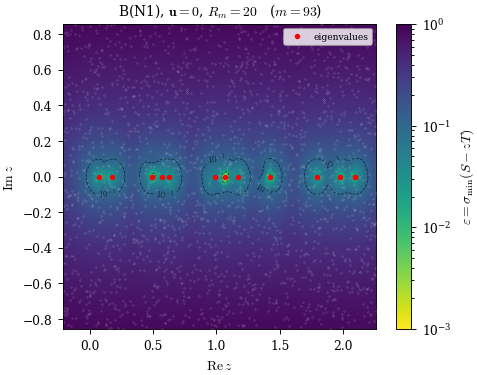

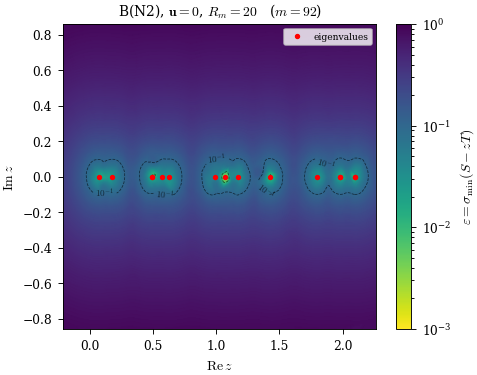

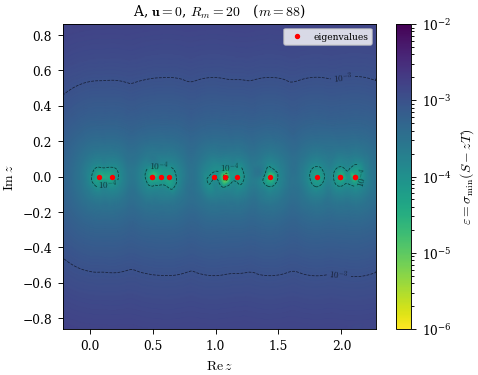

In [15]:
results_W0 = {}
with matplotlib.rc_context(PS_RC):
    for form_name in FORMS:
        r = pseudospectrum(form_name, mesh, "W0", Rm, TAU, nev=NEV, degree=DEGREE)
        results_W0[form_name] = r
        fig, ax = plt.subplots(figsize=(4.6, 3.6))
        plot_pseudospectrum(r, ax=ax, show_samples=(form_name == "B(N1)"))
        ax.legend(loc="upper right", fontsize=6)
        plt.show()
        print()

---
## 12. Test case 2 — $\mathbf{u} = (\operatorname{sign}(y-1),\, 0)$ (discontinuous shear)

Now the advective term is present.  Three things change and all three are visible in the
panels below:

* the spectrum spreads far to the right and **complex-conjugate pairs appear** (they must come
  in pairs: the matrices are real);
* the level sets stop being circular — they merge into wide lobes around clusters of
  eigenvalues, which is the signature of **non-normality**: a $z$ far from every eigenvalue can
  still have $\sigma_{\min}(zM-A)$ tiny, so the resolvent is enormous there;
* the smallest $\sigma_{\min}$ over the box drops by several decades relative to the
  $\mathbf{u}=\mathbf{0}$ panel of the same formulation, which is the quantitative statement of the
  same fact.

B(N1)  W3  N=  6017  dof=  6273  nconv=100  m=100
        QZ residual   : 1.95e-13   (unitary factorisation check)
        eig reproduced: 1.90e-06   (max |lambda_SLEPc - Ritz|)
        window        : Re [-0.799  6.739]  Im [-2.609  2.609]
        sigma_min     : [1.122e-07, 1.456e+00]  over 2000 random samples
        grid filled by nearest neighbour: 1.8% (outside the convex hull of the samples)

B(N2)  W3  N= 15105  dof= 15617  nconv=107  m=107
        QZ residual   : 1.56e-13   (unitary factorisation check)
        eig reproduced: 3.48e-06   (max |lambda_SLEPc - Ritz|)
        window        : Re [-0.798  6.741]  Im [-2.61  2.61]
        sigma_min     : [1.054e-07, 1.429e+00]  over 2000 random samples
        grid filled by nearest neighbour: 1.8% (outside the convex hull of the samples)

A      W3  N=  1602  dof=  1602  nconv= 82  m= 82
        QZ residual   : 1.74e-16   (unitary factorisation check)
        eig reproduced: 4.92e-08   (max |lambda_SLEPc - Ritz|)
        window    

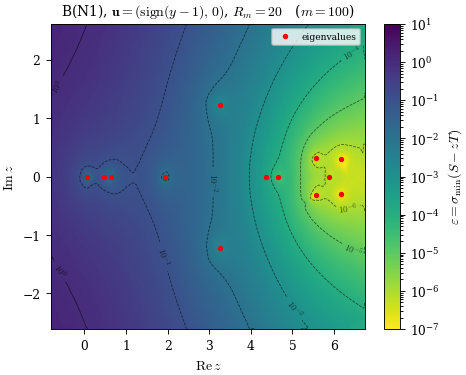

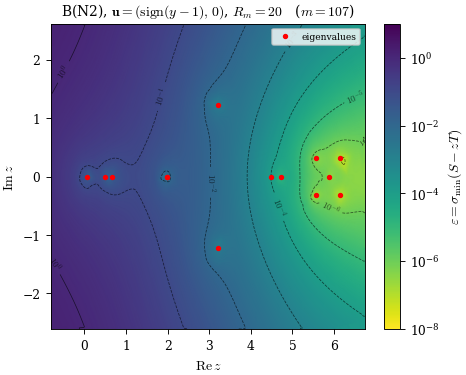

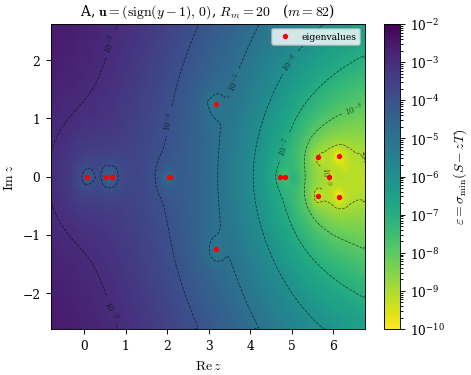

In [16]:
results_W3 = {}
with matplotlib.rc_context(PS_RC):
    for form_name in FORMS:
        r = pseudospectrum(form_name, mesh, "W3", Rm, TAU, nev=NEV, degree=DEGREE)
        results_W3[form_name] = r
        fig, ax = plt.subplots(figsize=(4.6, 3.6))
        plot_pseudospectrum(r, ax=ax)
        ax.legend(loc="upper right", fontsize=6)
        plt.show()
        print()

---
## 13. Summary grid

All six configurations on one figure.  Within each **column** the window is shared, so the three
formulations can be compared directly; the colour scales are *not* shared between columns
because the two winds produce spectra of very different extent, nor between the $B$ and $A$
rows because of the Euclidean-norm scaling noted in section 8.

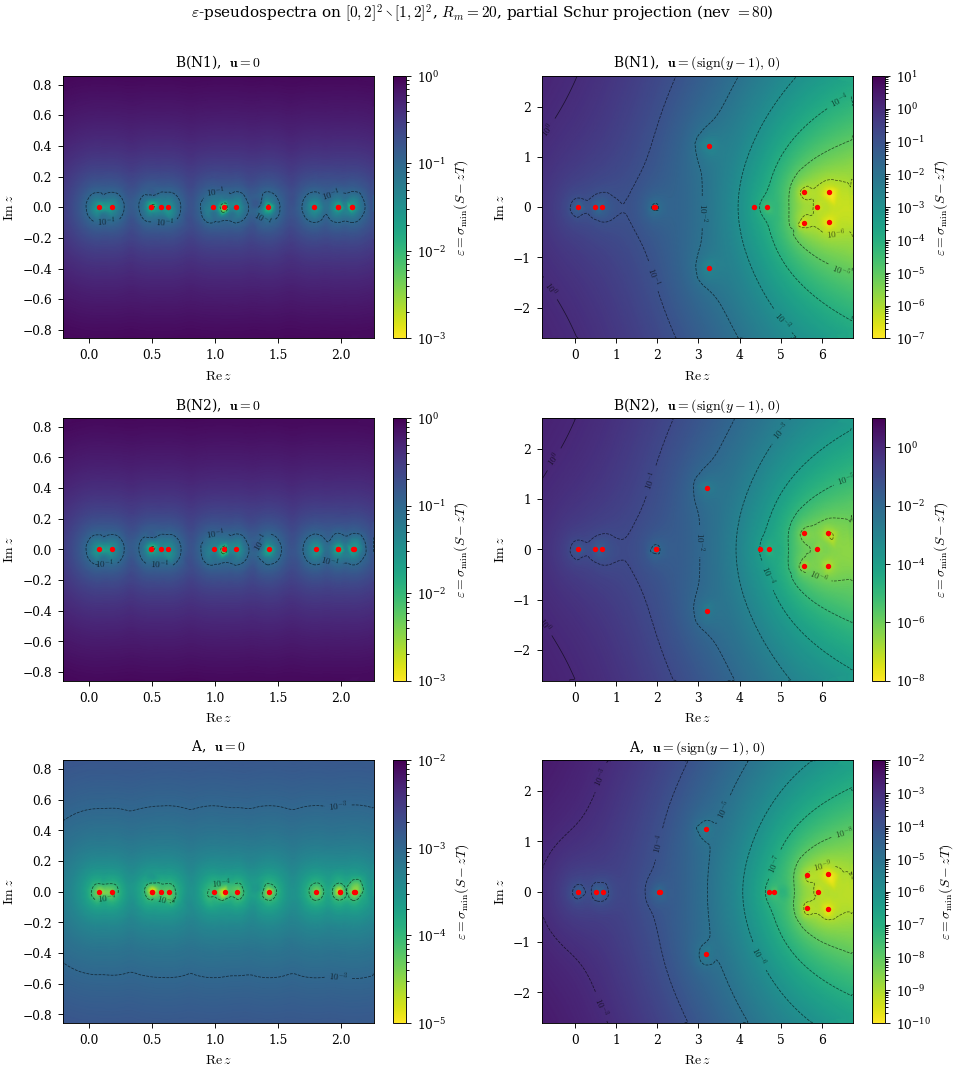

In [17]:
# Recompute with a window shared per wind (taken from the B(N1) case) so that the
# three rows are drawn on identical axes.
shared = {"W0": (results_W0["B(N1)"]["real_range"], results_W0["B(N1)"]["imag_range"]),
          "W3": (results_W3["B(N1)"]["real_range"], results_W3["B(N1)"]["imag_range"])}

with matplotlib.rc_context(PS_RC):
    fig, axes = plt.subplots(3, 2, figsize=(9.0, 10.0))
    for row, form_name in enumerate(FORMS):
        for col, wind_key in enumerate(["W0", "W3"]):
            cached = (results_W0 if wind_key == "W0" else results_W3)[form_name]
            r = (cached if cached["real_range"] == shared[wind_key][0]
                 else pseudospectrum(form_name, mesh, wind_key, Rm, TAU, nev=NEV,
                                     degree=DEGREE, window=shared[wind_key],
                                     verbose=False))
            plot_pseudospectrum(
                r, ax=axes[row, col],
                title=f"{form_name},  {r['wind_label']}")
    fig.suptitle(rf"$\varepsilon$-pseudospectra on $[0,2]^2\setminus[1,2]^2$, "
                 rf"$R_m={Rm:g}$, partial Schur projection (nev $={NEV}$)",
                 fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()

---
## 14. Convergence of the projection

The one-sided projection is an **inner** approximation:
$\sigma_{\min}(S - zT) \ge \sigma_{\min}(zM - A)$ pointwise, with equality in the limit
$m \to N$.  The contours therefore move *inward* (towards smaller $\varepsilon$) as $m$ grows and
must be checked for convergence before anything is quoted from them.

The cell below evaluates $\mathcal{R}$ at four fixed probe points for increasing `nev`.  Read
the numbers, not the picture: where they are still falling by an order of magnitude, the
subspace is too small at that $z$.

Watch `max|Ritz-lam|` at the same time.  It *rises* with `nev`, because the outermost
eigenpairs of a larger request are the least well converged, and they are exactly the ones a
one-sided projection reproduces worst.  Enlarging the subspace therefore buys a tighter
$\sigma_{\min}$ at the cost of a looser projection — there is no free convergence here, and a
run whose `max|Ritz-lam|` has grown to the size of the features being read off the plot is
no longer trustworthy.

In [18]:
probe = np.array([1.0 + 0.5j, 3.0 + 0.0j, 5.0 + 0.5j, 2.0 + 1.5j])
print("B(N1), u = (sign(y-1), 0):  R(z) = sigma_min(S - zT) at fixed probe points\n")
print("  nev    m   max|Ritz-lam|   " + "   ".join(f"z={z:g}" for z in probe))
for nev in (40, 80, 160):
    # Only S and T are wanted here, so the sampling and interpolation are cut
    # right down; griddata still needs enough points for a Delaunay triangulation.
    r = pseudospectrum("B(N1)", mesh, "W3", Rm, TAU, nev=nev, degree=DEGREE,
                       n_points=64, res=8, verbose=False)
    vals = [sla.svdvals(r["S"] - zk * r["T"])[-1] for zk in probe]
    print(f"  {nev:3d}  {r['m']:3d}   {r['eig_error']:.2e}      "
          + "  ".join(f"{v:.3e}" for v in vals))
print("\nsigma_min decreases monotonically with m, as it must for an inner approximation.")

B(N1), u = (sign(y-1), 0):  R(z) = sigma_min(S - zT) at fixed probe points

  nev    m   max|Ritz-lam|   z=1+0.5j   z=3+0j   z=5+0.5j   z=2+1.5j
   40   43   1.49e-07      2.070e-01  3.236e-02  2.241e-04  1.747e-01
   80  100   1.90e-06      1.459e-01  1.211e-02  3.751e-05  9.350e-02
  160  186   2.42e-04      1.292e-01  8.588e-03  2.014e-05  7.602e-02

sigma_min decreases monotonically with m, as it must for an inner approximation.


---
## 15. What the results say, and the caveats

**Findings.**

* With $\mathbf{u} = \mathbf{0}$ all three formulations give the same real spectrum, matching the
  reference L-shape eigenvalues to the discretisation error of $\mathrm{CG}_1$/$\mathrm{N1curl}_1$
  on $h = 1/16$, and the level sets are essentially circular: the operator is normal and the
  pseudospectra carry no information beyond the eigenvalues themselves.
* With the discontinuous shear $\mathbf{u} = (\operatorname{sign}(y-1), 0)$ at $R_m = 20$, all three
  formulations become markedly non-normal in the same places — the level sets bulge into wide
  lobes around eigenvalue clusters, and $\mathcal{R}$ falls several decades below what the
  distance to the nearest eigenvalue would predict.  The agreement between `B(N1)`, `B(N2)` and
  `A` is the useful outcome: the non-normality is a property of the operator, not an artefact
  of one choice of finite element space.

**Caveats that limit what may be quoted.**

1. *Inner approximation.*  Every contour is an upper bound on $\varepsilon$; the true
   pseudospectrum is at least as large as what is drawn.  Section 14 shows the values are still
   drifting at $m \approx 100$ in the far field of the window, so the shear panels should be
   read qualitatively unless re-run at larger `nev`.
2. *Euclidean norm.*  $Q$ is Euclidean-orthonormal, as specified, so $\sigma_{\min}$ carries the
   $O(h^d)$ scaling of the mass matrix.  Absolute levels are not comparable across
   formulations or across meshes — only within a fixed discretisation.
3. *Interpolation.*  $2000$ random samples resolve the broad structure well, but the contours
   inherit a little of the sampling noise, most visibly where the field is flat.  Raise
   `n_points` if a contour is needed to plotting accuracy rather than to reading accuracy.
4. *Window.*  The bounding box is built from the innermost Ritz values, so it lies inside the
   resolved part of the spectrum.  Widening it past the eigenvalues the subspace captured would
   produce a plot that looks fine and means nothing.